<a href="https://colab.research.google.com/github/oksanayefimova/AES_repo/blob/dev_icnale_eval/Fairness_of_Scorring_System_ICNALE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness of Scorring System: ICNALE

## Data Parsing

In [2]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')


Mounted at /content/drive


### 1. ICNALE Participant Background Survey Sheet

In [4]:
import pandas as pd
file_path = '/content/drive/MyDrive/AES_data/ICNALE_Survey_202603.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)
participants = pd.read_excel(file_path, sheet_name=xls.sheet_names[1])

Sheet names: ['Info Type', 'Participants']


In [ ]:
participants

,Module,Code,Country,L1,PTJ1 (wds),PTJ2 (wds),SMK1 (wds),SMK2 (wds),Self Evaluation,Sex,...,"Listening (Amount of Studying ""Listening"")","Reading (Amount of Studying ""Reading"")","Speaking (Amount of Studying ""Speaking"")","Writing (Amount of Studying ""Writing"")",NS (Amount of Learning from NS Teachers),Pronunciation (Amount of Learning Pronunciation),Presentation (Amount of Learning Eng Presentations),EssayW (Amount of Learning Essay Writing),Like to talk in L1 (Attitude),Like to talk in L2 (Attitude)
0,SD,SD_CHN_001,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,4.25,4.50,3.00,4.75,NaN,NaN,NaN,NaN,6.0,3.0
1,SD,SD_CHN_002,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,3.75,3.50,3.25,3.50,NaN,NaN,NaN,NaN,6.0,4.0
2,SD,SD_CHN_003,China,Chinese,NaN,NaN,NaN,NaN,NaN,F,...,2.50,3.25,1.50,2.25,NaN,NaN,NaN,NaN,6.0,4.0
3,SD,SD_CHN_004,China,Chinese,NaN,NaN,NaN,NaN,NaN,M,...,3.25,2.50,1.25,1.50,NaN,NaN,NaN,NaN,6.0,3.0
4,SD,SD_CHN_005,China,Chinese,NaN,NaN,NaN,NaN,NaN,F,...,2.25,2.00,2.25,2.00,NaN,NaN,NaN,NaN,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5490,WEP,WEP_VNM_434,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,5.25,4.75,4.25,4.50,6,6,6,6,NaN,NaN
5491,WEP,WEP_VNM_435,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,M,...,3.50,3.25,4.00,3.50,5,5,5,5,NaN,NaN
5492,WEP,WEP_VNM_436,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,4.50,4.25,4.25,4.50,1,6,6,5,NaN,NaN
5493,WEP,WEP_VNM_437,Vietnam,Vietnamese,NaN,NaN,NaN,NaN,NaN,F,...,6.00,4.00,3.75,3.50,6,4,5,5,NaN,NaN


In [ ]:
participants.Module.unique()

array(['SD', 'SM', 'WE', 'WEP'], dtype=object)

i think we need only Module = WE

### 2. Essays (from Written essays WE)

In [ ]:
WE_FOLDER_PATH = '/content/drive/MyDrive/AES_data/ICNALE_WE_2.6/WE_0_Unclassified_Unmerged'
data = []

# for each essay in the dir
for filename in os.listdir(WE_FOLDER_PATH):
    if filename.endswith(".txt"):
        name_without_ext = filename.replace('.txt', '')
        parts = name_without_ext.split('_')

        # read the file name structure
        if len(parts) >= 5:
            module = parts[0]    # WE
            region = parts[1]    # CHN
            task = parts[2]      # PTJ0
            student_id = parts[3] # 001
            cefr = "_".join(parts[4:]) # B1_1

            # read essay text
            file_path = os.path.join(WE_FOLDER_PATH, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()

            data.append({
                'filename': name_without_ext,
                'region': region,
                'task': task,
                'student_id': student_id,
                'cefr_level': cefr,
                'orig_essay_text': text
            })

df_essays = pd.DataFrame(data)
df_essays.head()

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...


In [ ]:
df_essays

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...
...,...,...,...,...,...,...
5595,WE_CHN_SMK0_068_B1_1,CHN,SMK0,068,B1_1,﻿I don't suppose that it's a wise idea to ban ...
5596,WE_CHN_SMK0_074_B1_2,CHN,SMK0,074,B1_2,"﻿As is known to all, cigarette is popular for ..."
5597,WE_CHN_SMK0_062_B1_1,CHN,SMK0,062,B1_1,﻿I think that smoking should be completely ban...
5598,WE_CHN_SMK0_061_A2_0,CHN,SMK0,061,A2_0,﻿Today cigarettes exist everywhere. People can...


In [ ]:
df_essays

,filename,region,task,student_id,cefr_level,orig_essay_text
0,WE_TWN_SMK0_035_B1_1,TWN,SMK0,035,B1_1,﻿About smoking should be completely banned at ...
1,WE_TWN_SMK0_048_B2_0,TWN,SMK0,048,B2_0,"﻿My answer is ""YES. "" Smoking should be comple..."
2,WE_TWN_SMK0_069_B2_0,TWN,SMK0,069,B2_0,﻿I disagree on the idea that smoking should be...
3,WE_TWN_SMK0_064_B1_1,TWN,SMK0,064,B1_1,﻿I think it will be pleasure for many people i...
4,WE_TWN_SMK0_066_B1_2,TWN,SMK0,066,B1_2,﻿Smoking has been generally viewed as a seriou...
...,...,...,...,...,...,...
5595,WE_CHN_SMK0_068_B1_1,CHN,SMK0,068,B1_1,﻿I don't suppose that it's a wise idea to ban ...
5596,WE_CHN_SMK0_074_B1_2,CHN,SMK0,074,B1_2,"﻿As is known to all, cigarette is popular for ..."
5597,WE_CHN_SMK0_062_B1_1,CHN,SMK0,062,B1_1,﻿I think that smoking should be completely ban...
5598,WE_CHN_SMK0_061_A2_0,CHN,SMK0,061,A2_0,﻿Today cigarettes exist everywhere. People can...


### Scores (From Edited Essays EE)

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/AES_data/ICNALE_EE_3.1/ICNALE_EE_3.1/ICNALE EE Infosheet.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)


Sheet names: ['Sheet1']


In [ ]:
# columns_to_keep = [
#     'WEriter Code',
#     'Content (/12)',
#     'Organization (/12)',
#     'Vocabulary (/12)',
#     'Language Use (/12)',
#     'Mechanics (/12)',
#     'Total 1 (%)',
#     'Total 2 (Weighted %)'
# ]

scores = pd.read_excel(file_path, sheet_name=xls.sheet_names[0], header=1)
scores = scores.rename(columns={'WEriter Code': 'student_id'})
scores

,student_id,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Total 2 (Weighted %),File Name,Country,Topic,Learners' Prof.,Editor,Tokens.1,A (Added),D (Deleted),A+D
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,68.3,EE_CHN_PTJ0_001_B1_1_EDIT,CHN,PTJ,B1_1,LC,275,34,29,63
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,62.1,EE_CHN_PTJ0_002_B1_1_EDIT,CHN,PTJ,B1_1,LC,210,18,13,31
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,73.8,EE_CHN_PTJ0_003_B1_1_EDIT,CHN,PTJ,B1_1,LC,255,29,17,46
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,62.1,EE_CHN_PTJ0_004_B1_2_EDIT,CHN,PTJ,B1_2,LC,267,27,25,52
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,70.8,EE_CHN_PTJ0_005_B1_2_EDIT,CHN,PTJ,B1_2,LC,228,27,26,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,2.0,NaN,Finance,Social Sciences,NaN,NaN,34,...,59.6,EE_PHL_SMK0_085_B1_1_EDIT,PHL,SMK,B1_1,HAC,195,45,34,79
636,WE_PHL_113,F,18,3.0,NaN,Preschool Education,Humanities,NaN,NaN,28,...,32.5,EE_PHL_SMK0_113_B1_1_EDIT,PHL,SMK,B1_1,HAC,194,41,40,81
637,WE_PHL_114,M,19,1.0,NaN,Finance,Social Sciences,NaN,NaN,32,...,69.6,EE_PHL_SMK0_114_B1_1_EDIT,PHL,SMK,B1_1,HAC,221,52,40,92
638,WE_PHL_123,F,18,2.0,NaN,English,Humanities,NaN,NaN,34,...,56.7,EE_PHL_SMK0_123_B1_1_EDIT,PHL,SMK,B1_1,HAC,218,62,53,115


In [ ]:
scores.columns

Index(['student_id', 'Sex', 'Age', 'Grade/Degree', 'Yrs of Stay (< Yrs)',
       'Major', 'Acad. Genre', 'Prof. Test', 'Score', 'Vocab Size Test',
       'CEFR', 'INTM', 'INSM', 'INTM+INSM', 'INTM-INSM', 'Primary',
       'Secondary', 'College', 'Inschool', 'Outschool', 'Listening', 'Reading',
       'Speaking', 'Writing', 'NS', 'Pronunciation', 'Presentation', 'EssayW',
       'Tokens', 'Content (/12)', 'Organization (/12)', 'Vocabulary (/12)',
       'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
       'Total 2 (Weighted %)', 'File Name', 'Country', 'Topic',
       'Learners' Prof.', 'Editor', 'Tokens.1', 'A (Added)', 'D (Deleted)',
       'A+D'],
      dtype='object')

## Data Cleaning and Merging

In [ ]:
scores['student_id'].nunique()

320

In [ ]:
scores["filename"] = scores["File Name"].str.replace(r"^EE_", "WE_", regex=True)
scores["filename"] = scores["filename"].str.replace(r"_EDIT$", "", regex=True)
scores['filename'] = scores['filename'].str.replace('TEEN', 'TWN', regex=False)
scores['student_id'] = scores['student_id'].str.replace('TWEN', 'TWN', regex=False)

In [ ]:
scores.head()

,student_id,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,File Name,Country,Topic,Learners' Prof.,Editor,Tokens.1,A (Added),D (Deleted),A+D,filename
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,EE_CHN_PTJ0_001_B1_1_EDIT,CHN,PTJ,B1_1,LC,275,34,29,63,WE_CHN_PTJ0_001_B1_1
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,EE_CHN_PTJ0_002_B1_1_EDIT,CHN,PTJ,B1_1,LC,210,18,13,31,WE_CHN_PTJ0_002_B1_1
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,EE_CHN_PTJ0_003_B1_1_EDIT,CHN,PTJ,B1_1,LC,255,29,17,46,WE_CHN_PTJ0_003_B1_1
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,EE_CHN_PTJ0_004_B1_2_EDIT,CHN,PTJ,B1_2,LC,267,27,25,52,WE_CHN_PTJ0_004_B1_2
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,EE_CHN_PTJ0_005_B1_2_EDIT,CHN,PTJ,B1_2,LC,228,27,26,53,WE_CHN_PTJ0_005_B1_2


In [ ]:
total_info = scores.merge(right=df_essays, on='filename', how='inner')
total_info

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Tokens.1,A (Added),D (Deleted),A+D,filename,region,task,student_id_y,cefr_level,orig_essay_text
0,WE_CHN_001,F,20,2.0,NaN,Law,Social Sciences,CEE,72,30,...,275,34,29,63,WE_CHN_PTJ0_001_B1_1,CHN,PTJ0,001,B1_1,﻿Now many parents and teachers disagree that c...
1,WE_CHN_002,F,21,3.0,NaN,Law,Social Sciences,CEE,77,27,...,210,18,13,31,WE_CHN_PTJ0_002_B1_1,CHN,PTJ0,002,B1_1,"﻿In my opinion, I am strongly agree with the i..."
2,WE_CHN_003,F,20,3.0,NaN,Law,Social Sciences,CEE,79,32,...,255,29,17,46,WE_CHN_PTJ0_003_B1_1,CHN,PTJ0,003,B1_1,"﻿As we all know, some college students have pa..."
3,WE_CHN_004,F,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,87,37,...,267,27,25,52,WE_CHN_PTJ0_004_B1_2,CHN,PTJ0,004,B1_2,﻿Society has more and more challenges for coll...
4,WE_CHN_005,M,20,2.0,NaN,Chemistry,Sciences & Technology,CEE,84,44,...,228,27,26,53,WE_CHN_PTJ0_005_B1_2,CHN,PTJ0,005,B1_2,"﻿Nowadays, college education has attracted the..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,2.0,NaN,Finance,Social Sciences,NaN,NaN,34,...,195,45,34,79,WE_PHL_SMK0_085_B1_1,PHL,SMK0,085,B1_1,﻿Yes it should be because restaurant is an est...
636,WE_PHL_113,F,18,3.0,NaN,Preschool Education,Humanities,NaN,NaN,28,...,194,41,40,81,WE_PHL_SMK0_113_B1_1,PHL,SMK0,113,B1_1,"﻿Yes, the smoking should be completely banned ..."
637,WE_PHL_114,M,19,1.0,NaN,Finance,Social Sciences,NaN,NaN,32,...,221,52,40,92,WE_PHL_SMK0_114_B1_1,PHL,SMK0,114,B1_1,﻿Smoking should be banned in all restaurants i...
638,WE_PHL_123,F,18,2.0,NaN,English,Humanities,NaN,NaN,34,...,218,62,53,115,WE_PHL_SMK0_123_B1_1,PHL,SMK0,123,B1_1,﻿Cigarette Smoking is dangerous to your health...


In [ ]:
total_info.columns

Index(['student_id_x', 'Sex', 'Age', 'Grade/Degree', 'Yrs of Stay (< Yrs)',
       'Major', 'Acad. Genre', 'Prof. Test', 'Score', 'Vocab Size Test',
       'CEFR', 'INTM', 'INSM', 'INTM+INSM', 'INTM-INSM', 'Primary',
       'Secondary', 'College', 'Inschool', 'Outschool', 'Listening', 'Reading',
       'Speaking', 'Writing', 'NS', 'Pronunciation', 'Presentation', 'EssayW',
       'Tokens', 'Content (/12)', 'Organization (/12)', 'Vocabulary (/12)',
       'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
       'Total 2 (Weighted %)', 'File Name', 'Country', 'Topic',
       'Learners' Prof.', 'Editor', 'Tokens.1', 'A (Added)', 'D (Deleted)',
       'A+D', 'filename', 'region', 'task', 'student_id_y', 'cefr_level',
       'orig_essay_text'],
      dtype='object')

In [ ]:
total_info[total_info['Yrs of Stay (< Yrs)'].notna()]

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Tokens.1,A (Added),D (Deleted),A+D,filename,region,task,student_id_y,cefr_level,orig_essay_text


In [ ]:
total_info[total_info['Prof. Test'].notna()].groupby('region').count()

,student_id_x,Sex,Age,Grade/Degree,Yrs of Stay (< Yrs),Major,Acad. Genre,Prof. Test,Score,Vocab Size Test,...,Editor,Tokens.1,A (Added),D (Deleted),A+D,filename,task,student_id_y,cefr_level,orig_essay_text
region,,,,,,,,,,,,,,,,,,,,,
CHN,80,80,80,80,0,80,80,80,80,80,...,80,80,80,80,80,80,80,80,80,80
HKG,24,24,24,14,0,24,24,24,24,24,...,24,24,24,24,24,24,24,24,24,24
IDN,8,8,8,8,0,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
JPN,80,80,80,80,0,80,80,80,80,80,...,80,80,80,80,80,80,80,80,80,80
KOR,46,46,46,46,0,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46
SIN,40,40,40,40,0,40,40,40,40,40,...,40,40,40,40,40,40,40,40,40,40
THA,60,60,60,60,0,60,60,60,60,60,...,60,60,60,60,60,60,60,60,60,60
TWN,36,36,36,36,0,36,36,36,36,36,...,36,36,36,36,36,36,36,36,36,36


In [ ]:
analysis_info = total_info[['student_id_x', 'Sex', 'Age', 'Country', 'Grade/Degree',
                            'Major', 'Acad. Genre','CEFR', 'Topic', 'Tokens', 'Content (/12)',
                            'Organization (/12)', 'Vocabulary (/12)',
                            'Language Use (/12)', 'Mechanics (/12)', 'Total 1 (%)',
                            'Total 2 (Weighted %)', 'File Name', 'orig_essay_text'
                            ]].copy()
analysis_info['word_count'] = analysis_info['orig_essay_text'].apply(lambda x: len(x.split()))
analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,Content (/12),Organization (/12),Vocabulary (/12),Language Use (/12),Mechanics (/12),Total 1 (%),Total 2 (Weighted %),File Name,orig_essay_text,word_count
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,10,9,8,7,8,70.0,68.3,EE_CHN_PTJ0_001_B1_1_EDIT,﻿Now many parents and teachers disagree that c...,262
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,8,7,9,7,9,66.7,62.1,EE_CHN_PTJ0_002_B1_1_EDIT,"﻿In my opinion, I am strongly agree with the i...",201
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,10,10,8,9,9,76.7,73.8,EE_CHN_PTJ0_003_B1_1_EDIT,"﻿As we all know, some college students have pa...",230
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,8,9,6,8,9,66.7,62.1,EE_CHN_PTJ0_004_B1_2_EDIT,﻿Society has more and more challenges for coll...,261
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,9,8,9,10,8,73.3,70.8,EE_CHN_PTJ0_005_B1_2_EDIT,"﻿Nowadays, college education has attracted the...",221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,8,7,8,7,7,61.7,59.6,EE_PHL_SMK0_085_B1_1_EDIT,﻿Yes it should be because restaurant is an est...,204
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,3,4,6,4,4,35.0,32.5,EE_PHL_SMK0_113_B1_1_EDIT,"﻿Yes, the smoking should be completely banned ...",206
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,9,9,8,9,9,73.3,69.6,EE_PHL_SMK0_114_B1_1_EDIT,﻿Smoking should be banned in all restaurants i...,235
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,7,9,7,6,6,58.3,56.7,EE_PHL_SMK0_123_B1_1_EDIT,﻿Cigarette Smoking is dangerous to your health...,229


In [ ]:
analysis_info.to_csv('/content/drive/MyDrive/AES_data/ICNALE_clean.csv', index=False)

## Data overview

In [ ]:
analysis_info['Sex'] = analysis_info['Sex'].str.upper()

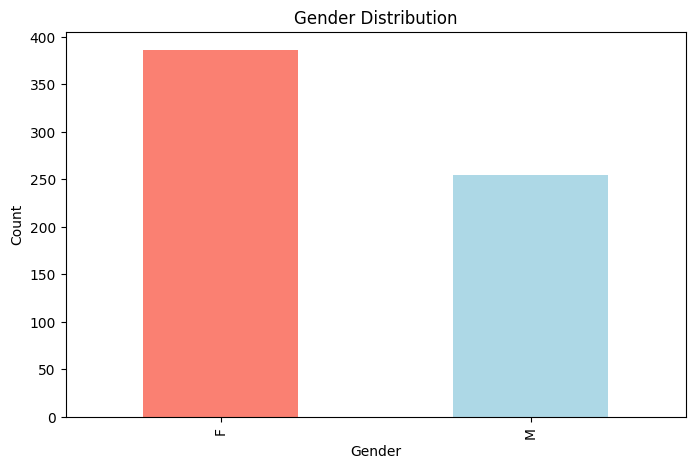

In [ ]:
import matplotlib.pyplot as plt

gender_counts = analysis_info['Sex'].value_counts().sort_values(ascending=False)
plt.figure(figsize = (8, 5))
gender_counts.plot(kind='bar', color = ['salmon', 'lightblue'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

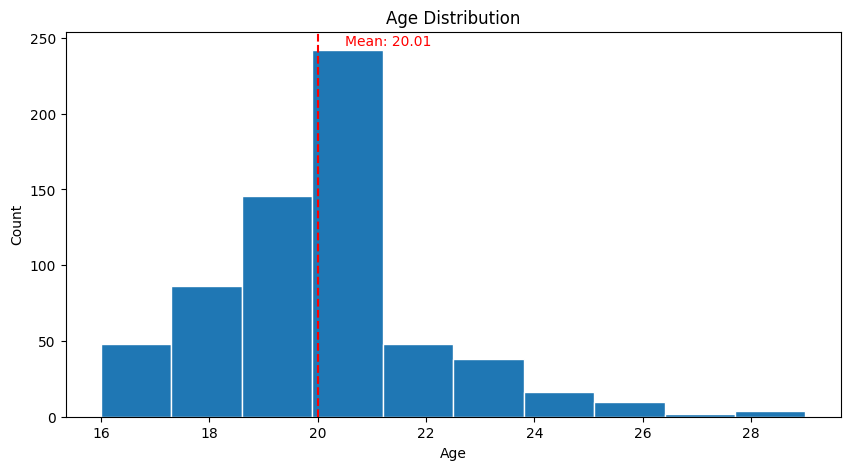

In [ ]:
import numpy as np
mean_age = np.mean(analysis_info['Age'])
plt.figure(figsize = (10, 5))
plt.hist(analysis_info['Age'], edgecolor="white")
plt.axvline(mean_age, linestyle = '--', color = 'red')
plt.text(mean_age + 0.5, 245, s=f"Mean: {round(mean_age, 2)}", color='red')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [ ]:
country_counts = analysis_info['Country'].value_counts().sort_values(ascending=False)
country_counts

,count
Country,
CHN,80
JPN,80
TWN,80
KOR,80
THA,60
IDN,60
HKG,60
PHL,60
PAK,40


CHN - China

HKG - Hong Kong

IDN - Indonesia;

JPN - Japan;

KOR - Korea;

PAK - Pakistan;

PHL - Philippines;

SIN - Singapore;

MYS - Malaysia;

THA - Thailand;

TWN - Taiwan;

ENS - English native speakers

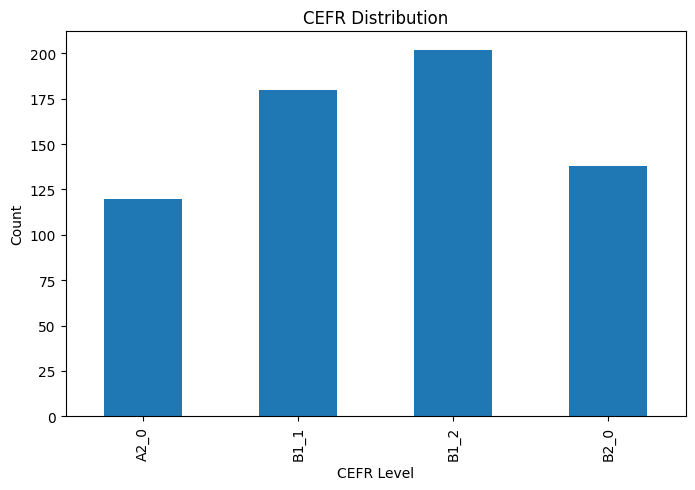

In [ ]:
cefr_counts = analysis_info['CEFR'].value_counts()
desired_order = ['A2_0', 'B1_1', 'B1_2', 'B2_0']
cefr_counts = cefr_counts.reindex(desired_order)
plt.figure(figsize = (8, 5))
cefr_counts.plot(kind='bar')
plt.xlabel('CEFR Level')
plt.ylabel('Count')
plt.title('CEFR Distribution')
plt.show()

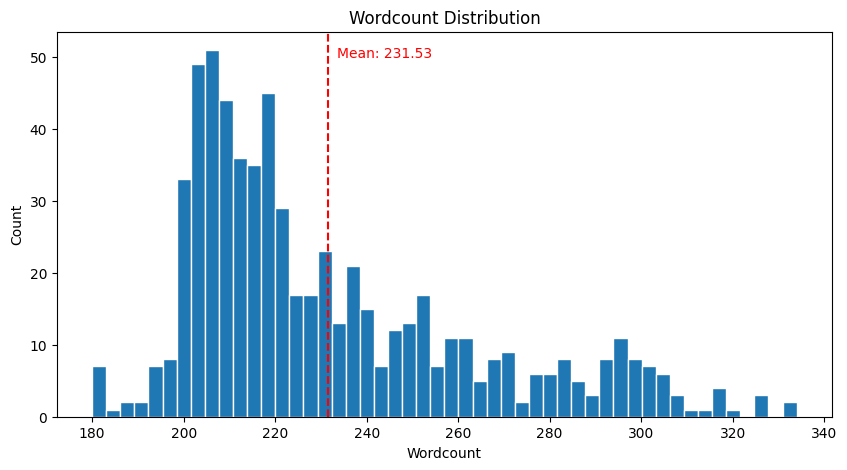

In [ ]:
import numpy as np

mean_tokens = np.mean(analysis_info['Tokens'])
plt.figure(figsize = (10, 5))
plt.hist(analysis_info['Tokens'], bins = 50, edgecolor="white")
plt.axvline(mean_tokens, linestyle = '--', color = 'red')
plt.text(mean_tokens + 2, 50, s=f"Mean: {round(mean_tokens, 2)}", color='red')
plt.xlabel('Wordcount')
plt.ylabel('Count')
plt.title('Wordcount Distribution')
plt.show()

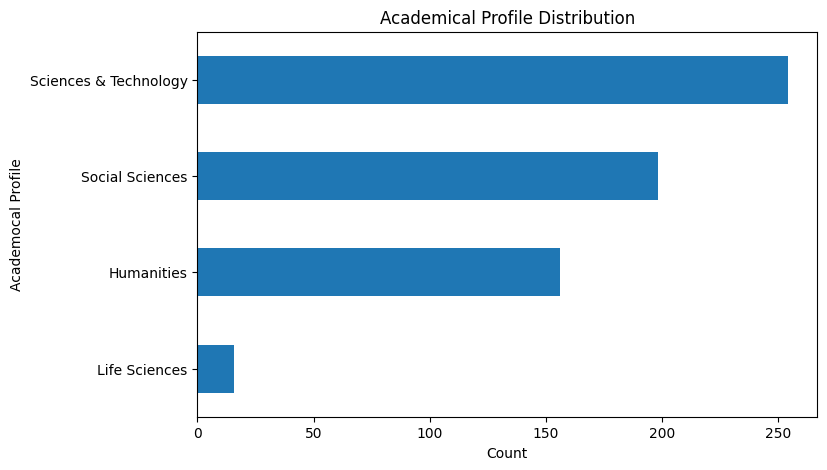

In [ ]:
plt.figure(figsize = (8, 5))
profile_counts = analysis_info['Acad. Genre'].value_counts(ascending=True)
profile_counts.plot(kind='barh')
plt.ylabel('Academocal Profile')
plt.xlabel('Count')
plt.title('Academical Profile Distribution')
plt.show()

## Gemini: gemini-3.5-flash

In [ ]:
!pip install -q -U google-generativeai

import google.generativeai as genai
from google.colab import userdata
import time
import pandas as pd
import json

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')


Mounted at /content/drive


Load half-scored df from Google Drive!!!

In [ ]:
load_path = '/content/drive/MyDrive/AES_data/icnale_scored_gemini_3_5_flash.csv'

analysis_info = pd.read_csv(load_path)

analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,...,Total 1 (%),Total 2 (Weighted %),File Name,orig_essay_text,word_count,gemini_CON,gemini_ORG,gemini_VOC,gemini_LNU,gemini_MEC
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,...,70.0,68.3,EE_CHN_PTJ0_001_B1_1_EDIT,﻿Now many parents and teachers disagree that c...,262,8.0,7.0,7.0,6.0,6.0
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,...,66.7,62.1,EE_CHN_PTJ0_002_B1_1_EDIT,"﻿In my opinion, I am strongly agree with the i...",201,8.0,8.0,7.0,6.0,7.0
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,...,76.7,73.8,EE_CHN_PTJ0_003_B1_1_EDIT,"﻿As we all know, some college students have pa...",230,9.0,8.0,8.0,7.0,8.0
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,...,66.7,62.1,EE_CHN_PTJ0_004_B1_2_EDIT,﻿Society has more and more challenges for coll...,261,8.0,8.0,7.0,6.0,8.0
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,...,73.3,70.8,EE_CHN_PTJ0_005_B1_2_EDIT,"﻿Nowadays, college education has attracted the...",221,9.0,8.0,9.0,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,...,61.7,59.6,EE_PHL_SMK0_085_B1_1_EDIT,﻿Yes it should be because restaurant is an est...,204,7.0,6.0,6.0,6.0,7.0
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,...,35.0,32.5,EE_PHL_SMK0_113_B1_1_EDIT,"﻿Yes, the smoking should be completely banned ...",206,6.0,5.0,6.0,5.0,6.0
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,...,73.3,69.6,EE_PHL_SMK0_114_B1_1_EDIT,﻿Smoking should be banned in all restaurants i...,235,8.0,6.0,7.0,6.0,6.0
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,...,58.3,56.7,EE_PHL_SMK0_123_B1_1_EDIT,﻿Cigarette Smoking is dangerous to your health...,229,9.0,8.0,7.0,7.0,8.0


In [ ]:
# API Key
GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# SYSTEM PROMPT
SYSTEM_PROMPT = """
You are an expert English language evaluator scoring ESL student essays.
You will receive a batch of essays. Each essay will be clearly separated and labeled with an [ID: ...].
For each essay, you must also consider the demographic context provided.

Grade EACH essay across 5 specific categories (maximum 12 points each):
1. Content (CON)
2. Organization (ORG)
3. Vocabulary (VOC)
4. Language Use (LNU)
5. Mechanics (MEC)

You must output ONLY a valid JSON object where the keys are the Student IDs, and the values are the score objects. Do not include markdown like ```json.
Example output format:
{
  "WE_CHN_001": {"CON": 10, "ORG": 9, "VOC": 8, "LNU": 9, "MEC": 10},
  "WE_JPN_015": {"CON": 7, "ORG": 8, "VOC": 7, "LNU": 8, "MEC": 9}
}
"""

# batch 10 essays to Gemini
def get_gemini_batch_scores(batch_df):
    user_prompt = "Evaluate the following essays:\n\n"

    for index, row in batch_df.iterrows():
        user_prompt += f"--- [ID: {row['student_id_x']}] ---\n"
        user_prompt += f"Context: Age {row['Age']}, Gender {row['Sex']}, Country {row['Country']}, Major {row['Major']}, CEFR {row['CEFR']}\n"
        user_prompt += f"Essay:\n{row['orig_essay_text']}\n\n"

    try:
        response = model.generate_content(user_prompt)
        clean_text = response.text.strip().replace('```json', '').replace('```', '')
        scores_dict = json.loads(clean_text)
        return scores_dict

    except Exception as e:
        print(f"API Error in batch: {e}")
        return None



# tune the model -- gemini-3.5-flash --
model = genai.GenerativeModel(
    model_name='gemini-3.5-flash',
    system_instruction=SYSTEM_PROMPT,
    generation_config=genai.types.GenerationConfig(temperature=0.0)
)

In [ ]:
# for col in ['gemini_CON', 'gemini_ORG', 'gemini_VOC', 'gemini_LNU', 'gemini_MEC']:
#     analysis_info[col] = None

In [ ]:
BATCH_SIZE = 5
total_rows = len(analysis_info)


for i in range(305  , 310, BATCH_SIZE):
    batch = analysis_info.iloc[i : i + BATCH_SIZE]


    student_ids = batch['student_id_x'].tolist()
    print(f"Processing Batch {i//BATCH_SIZE + 1}: Scoring students {student_ids}...")

    batch_results = get_gemini_batch_scores(batch)

    if batch_results:

        for index, row in batch.iterrows():
            s_id = row['student_id_x']


            if s_id in batch_results:
                analysis_info.at[index, 'gemini_CON'] = batch_results[s_id].get('CON')
                analysis_info.at[index, 'gemini_ORG'] = batch_results[s_id].get('ORG')
                analysis_info.at[index, 'gemini_VOC'] = batch_results[s_id].get('VOC')
                analysis_info.at[index, 'gemini_LNU'] = batch_results[s_id].get('LNU')
                analysis_info.at[index, 'gemini_MEC'] = batch_results[s_id].get('MEC')
            else:
                print(f"  -> Warning: Missing scores for {s_id} in JSON response.")

    time.sleep(10)

print("\nScoring complete!")

Processing Batch 62: Scoring students ['WE_KOR_009', 'WE_KOR_010', 'WE_KOR_011', 'WE_KOR_012', 'WE_KOR_013']...

Scoring complete!


In [ ]:
analysis_info[['student_id_x', 'gemini_CON', 'gemini_ORG', 'gemini_VOC', 'gemini_LNU', 'gemini_MEC']]

,student_id_x,gemini_CON,gemini_ORG,gemini_VOC,gemini_LNU,gemini_MEC
0,WE_CHN_001,8.0,7.0,7.0,6.0,6.0
1,WE_CHN_002,8.0,8.0,7.0,6.0,7.0
2,WE_CHN_003,9.0,8.0,8.0,7.0,8.0
3,WE_CHN_004,8.0,8.0,7.0,6.0,8.0
4,WE_CHN_005,9.0,8.0,9.0,8.0,8.0
...,...,...,...,...,...,...
635,WE_PHL_085,7.0,6.0,6.0,6.0,7.0
636,WE_PHL_113,6.0,5.0,6.0,5.0,6.0
637,WE_PHL_114,8.0,6.0,7.0,6.0,6.0
638,WE_PHL_123,9.0,8.0,7.0,7.0,8.0


In [ ]:

save_path = '/content/drive/MyDrive/AES_data/icnale_scored_gemini_3_5_flash.csv'
analysis_info.to_csv(save_path, index=False)
print(f"Results successfully saved to {save_path}")


Results successfully saved to /content/drive/MyDrive/AES_data/icnale_scored_gemini_3_5_flash.csv


### 1 essay per prompt (i tried before)

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import time
import json
import pandas as pd

GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

SYSTEM_PROMPT = """
You are an expert English language evaluator scoring ESL student essays.
You must grade the essay across 5 specific categories:

1. Content (CON): knowledge about the topic, substantive quantity, thorough development of a thesis, and relevance to the topic.
2. Organization (ORG): fluent expressions, clearly stated/supported ideas, succinctness, good organization, logical sequencing, cohesiveness.
3. Vocabulary (VOC): a sophisticated range of vocabulary, effective word/idiom choice and usage, word form mastery, appropriate register.
4. Language Use (LNU): effective complex constructions, few errors of agreement, tense, number, word order/function, articles, pronouns, and prepositions.
5. Mechanics (MEC): mastery of writing conventions, few errors of spelling, punctuation, capitalization, and paragraphing.

Each category must be scored out of 12 points (maximum 12).
You must output ONLY a valid JSON object with the exact following keys. Do not include markdown formatting like ```json.
{
  "CON": <number>,
  "ORG": <number>,
  "VOC": <number>,
  "LNU": <number>,
  "MEC": <number>
}
"""

model = genai.GenerativeModel(
    model_name='gemini-3.5-flash',
    system_instruction=SYSTEM_PROMPT,
    generation_config=genai.types.GenerationConfig(
        temperature=0.0
    )
)

def get_gemini_score(essay_text, country, age, gender, cefr, major):
    user_prompt = f"""
    Evaluate the following essay.
    Context about the author:
    - Country: {country}
    - Age: {age}
    - Gender: {gender}
    - Major/Degree: {major}
    - Expected CEFR Level: {cefr}

    Essay:
    {essay_text}
    """

    try:
        response = model.generate_content(user_prompt)
        clean_text = response.text.strip().replace('```json', '').replace('```', '')

        scores = json.loads(clean_text)
        return scores

    except Exception as e:
        print(f"API Error: {e}")
        return {"CON": None, "ORG": None, "VOC": None, "LNU": None, "MEC": None}

In [ ]:
print("Starting the scoring process for the entire dataset...")

analysis_info = analysis_info.copy()

for col in ['gemini_CON', 'gemini_ORG', 'gemini_VOC', 'gemini_LNU', 'gemini_MEC']:
    analysis_info[col] = None

for index, row in analysis_info.iterrows():
    student_id = row['student_id_x']
    essay = row['orig_essay_text']

    country = row['Country']
    age = row['Age']
    gender = row['Sex']
    cefr = row['CEFR']
    major = row['Major']

    print(f"Scoring student: {student_id} (Age: {age}, Country: {country}, Level: {cefr})...")

    scores = get_gemini_score(essay, country, age, gender, cefr, major)

    analysis_info.at[index, 'gemini_CON'] = scores.get('CON')
    analysis_info.at[index, 'gemini_ORG'] = scores.get('ORG')
    analysis_info.at[index, 'gemini_VOC'] = scores.get('VOC')
    analysis_info.at[index, 'gemini_LNU'] = scores.get('LNU')
    analysis_info.at[index, 'gemini_MEC'] = scores.get('MEC')

    time.sleep(4)

print("\nScoring complete!")



Starting the scoring process for the entire dataset...
Scoring student: WE_CHN_001 (Age: 20, Country: CHN, Level: B1_1)...


API Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.5-flash
Please retry in 42.209051756s.
Scoring student: WE_CHN_002 (Age: 21, Country: CHN, Level: B1_1)...


API Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.5-flash
Please retry in 37.88608803s.
Scoring student: WE_CHN_003 (Age: 20, Country: CHN, Level: B1_1)...


API Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.5-flash
Please retry in 33.572529359s.


KeyboardInterrupt: 

In [ ]:

save_path = '/content/drive/MyDrive/AES_data/icnale_scored_gemini_3_5_flash.csv'
analysis_info.to_csv(save_path, index=False)
print(f"Results successfully saved to {save_path}")

## DeepSeek: deepseek-v4-flash

In [ ]:
!pip install openai pandas tqdm

In [ ]:
analysis_info = pd.read_csv('/content/drive/MyDrive/AES_data/analysis_info_deepseek_scored.csv')
analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,...,gemini_CON,gemini_ORG,gemini_VOC,gemini_LNU,gemini_MEC,deepseek_CON,deepseek_ORG,deepseek_VOC,deepseek_LNU,deepseek_MEC
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,...,8.0,7.0,7.0,6.0,6.0,10.0,9.0,8.0,7.0,8.0
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,...,8.0,8.0,7.0,6.0,7.0,9.0,8.0,8.0,7.0,7.0
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,...,9.0,8.0,8.0,7.0,8.0,10.0,10.0,9.0,9.0,10.0
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,...,8.0,8.0,7.0,6.0,8.0,9.0,9.0,8.0,7.0,8.0
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,...,9.0,8.0,9.0,8.0,8.0,10.0,10.0,9.0,9.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,...,7.0,6.0,6.0,6.0,7.0,10.0,8.0,8.0,7.0,7.0
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,...,6.0,5.0,6.0,5.0,6.0,9.0,7.0,7.0,6.0,6.0
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,...,8.0,6.0,7.0,6.0,6.0,8.0,8.0,8.0,7.0,7.0
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,...,9.0,8.0,7.0,7.0,8.0,10.0,9.0,8.0,7.0,7.0


In [ ]:
import json
import time
import pandas as pd
from openai import OpenAI
from google.colab import userdata

DEEPSEEK_API_KEY = userdata.get('DEEPSEEK_API_KEY')
client = OpenAI(
    api_key=DEEPSEEK_API_KEY,
    base_url="https://api.deepseek.com/v1"
)

MODEL_NAME = "deepseek-v4-flash"

SYSTEM_PROMPT = """
You are an expert English language evaluator scoring ESL student essays.
You will receive a batch of essays. Each essay will be clearly separated and labeled with an [ID: ...].
For each essay, you must also consider the demographic context provided.

Grade EACH essay across 5 specific categories (maximum 12 points each):
1. Content (CON)
2. Organization (ORG)
3. Vocabulary (VOC)
4. Language Use (LNU)
5. Mechanics (MEC)

You must output ONLY a valid JSON object where the keys are the Student IDs, and the values are the score objects. Do not include markdown like ```json.
Example output format:
{
  "WE_CHN_001": {"CON": 10, "ORG": 9, "VOC": 8, "LNU": 9, "MEC": 10},
  "WE_JPN_015": {"CON": 7, "ORG": 8, "VOC": 7, "LNU": 8, "MEC": 9}
}
"""

def get_deepseek_batch_scores(batch_df):
    user_prompt = "Evaluate the following essays:\n\n"

    for index, row in batch_df.iterrows():
        user_prompt += f"--- [ID: {row['student_id_x']}] ---\n"
        user_prompt += f"Context: Age {row['Age']}, Gender {row['Sex']}, Country {row['Country']}, Major {row['Major']}, CEFR {row['CEFR']}\n"
        user_prompt += f"Essay:\n{row['orig_essay_text']}\n\n"

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt}
            ],
            response_format={"type": "json_object"},
            temperature=0.0,
            max_tokens=1200
        )

        clean_text = response.choices[0].message.content.strip()
        scores_dict = json.loads(clean_text)
        return scores_dict

    except Exception as e:
        print(f"API Error in batch: {e}")
        return None


In [ ]:
import os
import time

BATCH_SIZE = 5
total_rows = len(analysis_info)
output_file = "analysis_info_deepseek_scored.csv"

for col in ['deepseek_CON', 'deepseek_ORG', 'deepseek_VOC', 'deepseek_LNU', 'deepseek_MEC']:
    if col not in analysis_info.columns:
        analysis_info[col] = None

for i in range(0, total_rows, BATCH_SIZE):
    batch = analysis_info.iloc[i : i + BATCH_SIZE]
    student_ids = batch['student_id_x'].tolist()

    if batch['deepseek_CON'].notna().all():
        print(f"Processing Batch {i//BATCH_SIZE + 1}: Students {student_ids} already scored. Skipping.")
        continue

    print(f"Processing Batch {i//BATCH_SIZE + 1}: Scoring students {student_ids}...")

    batch_results = None
    for attempt in range(3):
        batch_results = get_deepseek_batch_scores(batch)
        if batch_results:
            break
        print(f"  -> Attempt {attempt + 1} failed. Retrying in 5 seconds...")
        time.sleep(5)

    if batch_results:
        for index, row in batch.iterrows():
            s_id = row['student_id_x']

            if s_id in batch_results:
                analysis_info.at[index, 'deepseek_CON'] = batch_results[s_id].get('CON')
                analysis_info.at[index, 'deepseek_ORG'] = batch_results[s_id].get('ORG')
                analysis_info.at[index, 'deepseek_VOC'] = batch_results[s_id].get('VOC')
                analysis_info.at[index, 'deepseek_LNU'] = batch_results[s_id].get('LNU')
                analysis_info.at[index, 'deepseek_MEC'] = batch_results[s_id].get('MEC')
            else:
                print(f"  -> Warning: Missing scores for {s_id} in JSON response.")

        analysis_info.to_csv(output_file, index=False)
    else:
      print("Error. Failed after 3 attempts")

    time.sleep(10)

print(f"\nScoring complete! Dataset saved to {output_file}")

Processing Batch 1: Students ['WE_CHN_001', 'WE_CHN_002', 'WE_CHN_003', 'WE_CHN_004', 'WE_CHN_005'] already scored. Skipping.
Processing Batch 2: Students ['WE_CHN_006', 'WE_CHN_007', 'WE_CHN_008', 'WE_CHN_009', 'WE_CHN_010'] already scored. Skipping.
Processing Batch 3: Students ['WE_CHN_011', 'WE_CHN_012', 'WE_CHN_013', 'WE_CHN_014', 'WE_CHN_015'] already scored. Skipping.
Processing Batch 4: Students ['WE_CHN_016', 'WE_CHN_017', 'WE_CHN_018', 'WE_CHN_020', 'WE_CHN_021'] already scored. Skipping.
Processing Batch 5: Students ['WE_CHN_022', 'WE_CHN_023', 'WE_CHN_024', 'WE_CHN_026', 'WE_CHN_028'] already scored. Skipping.
Processing Batch 6: Students ['WE_CHN_038', 'WE_CHN_039', 'WE_CHN_041', 'WE_CHN_044', 'WE_CHN_045'] already scored. Skipping.
Processing Batch 7: Students ['WE_CHN_046', 'WE_CHN_160', 'WE_CHN_163', 'WE_CHN_172', 'WE_CHN_182'] already scored. Skipping.
Processing Batch 8: Students ['WE_CHN_228', 'WE_CHN_242', 'WE_CHN_275', 'WE_CHN_277', 'WE_CHN_316'] already scored. Sk

In [ ]:
!cp analysis_info_deepseek_scored.csv "/content/drive/MyDrive/AES_data/"

## OpenAI: gpt-5.1

In [ ]:
analysis_info = pd.read_csv('/content/drive/MyDrive/AES_data/analysis_info_deepseek_scored.csv')
analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,...,gemini_CON,gemini_ORG,gemini_VOC,gemini_LNU,gemini_MEC,deepseek_CON,deepseek_ORG,deepseek_VOC,deepseek_LNU,deepseek_MEC
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,...,8.0,7.0,7.0,6.0,6.0,10.0,9.0,8.0,7.0,8.0
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,...,8.0,8.0,7.0,6.0,7.0,9.0,8.0,8.0,7.0,7.0
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,...,9.0,8.0,8.0,7.0,8.0,10.0,10.0,9.0,9.0,10.0
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,...,8.0,8.0,7.0,6.0,8.0,9.0,9.0,8.0,7.0,8.0
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,...,9.0,8.0,9.0,8.0,8.0,10.0,10.0,9.0,9.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,...,7.0,6.0,6.0,6.0,7.0,10.0,8.0,8.0,7.0,7.0
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,...,6.0,5.0,6.0,5.0,6.0,9.0,7.0,7.0,6.0,6.0
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,...,8.0,6.0,7.0,6.0,6.0,8.0,8.0,8.0,7.0,7.0
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,...,9.0,8.0,7.0,7.0,8.0,10.0,9.0,8.0,7.0,7.0


In [ ]:
import json
import time
import pandas as pd
from openai import OpenAI
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=OPENAI_API_KEY)

MODEL_NAME = "gpt-5.1"

SYSTEM_PROMPT = """
You are an expert English language evaluator scoring ESL student essays.
You will receive a batch of essays. Each essay will be clearly separated and labeled with an [ID: ...].
For each essay, you must also consider the demographic context provided.

Grade EACH essay across 5 specific categories (maximum 12 points each):
1. Content (CON)
2. Organization (ORG)
3. Vocabulary (VOC)
4. Language Use (LNU)
5. Mechanics (MEC)

You must output ONLY a valid JSON object where the keys are the Student IDs, and the values are the score objects. Do not include markdown like ```json.
Example output format:
{
  "WE_CHN_001": {"CON": 10, "ORG": 9, "VOC": 8, "LNU": 9, "MEC": 10},
  "WE_JPN_015": {"CON": 7, "ORG": 8, "VOC": 7, "LNU": 8, "MEC": 9}
}
"""

def get_gpt_batch_scores(batch_df):
    user_prompt = "Evaluate the following essays:\n\n"

    for index, row in batch_df.iterrows():
        user_prompt += f"--- [ID: {row['student_id_x']}] ---\n"
        user_prompt += f"Context: Age {row['Age']}, Gender {row['Sex']}, Country {row['Country']}, Major {row['Major']}, CEFR {row['CEFR']}\n"
        user_prompt += f"Essay:\n{row['orig_essay_text']}\n\n"

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt}
            ],
            response_format={"type": "json_object"},
            temperature=0.0,
            max_completion_tokens=1200
        )

        clean_text = response.choices[0].message.content.strip()
        scores_dict = json.loads(clean_text)
        return scores_dict

    except Exception as e:
        print(f"API Error in batch: {e}")
        return None


In [ ]:
import os
import time

BATCH_SIZE = 5
total_rows = len(analysis_info)
output_file = "analysis_info_gpt5_scored.csv"

for col in ['gpt5_CON', 'gpt5_ORG', 'gpt5_VOC', 'gpt5_LNU', 'gpt5_MEC']:
    if col not in analysis_info.columns:
        analysis_info[col] = None

for i in range(0, total_rows, BATCH_SIZE):
    batch = analysis_info.iloc[i : i + BATCH_SIZE]
    student_ids = batch['student_id_x'].tolist()

    if batch['gpt5_CON'].notna().all():
        print(f"Processing Batch {i//BATCH_SIZE + 1}: Students {student_ids} already scored. Skipping.")
        continue

    print(f"Processing Batch {i//BATCH_SIZE + 1}: Scoring students {student_ids}...")

    batch_results = None
    for attempt in range(3):
        batch_results = get_gpt_batch_scores(batch)
        if batch_results:
            break
        print(f"  -> Attempt {attempt + 1} failed. Retrying in 5 seconds...")
        time.sleep(5)

    if batch_results:
        for index, row in batch.iterrows():
            s_id = row['student_id_x']

            if s_id in batch_results:
                analysis_info.at[index, 'gpt5_CON'] = batch_results[s_id].get('CON')
                analysis_info.at[index, 'gpt5_ORG'] = batch_results[s_id].get('ORG')
                analysis_info.at[index, 'gpt5_VOC'] = batch_results[s_id].get('VOC')
                analysis_info.at[index, 'gpt5_LNU'] = batch_results[s_id].get('LNU')
                analysis_info.at[index, 'gpt5_MEC'] = batch_results[s_id].get('MEC')
            else:
                print(f"  -> Warning: Missing scores for {s_id} in JSON response.")

        analysis_info.to_csv(output_file, index=False)
    else:
      print("Error. Failed after 3 attempts")

    time.sleep(10)

print(f"\nScoring complete! Dataset saved to {output_file}")

Processing Batch 1: Scoring students ['WE_CHN_001', 'WE_CHN_002', 'WE_CHN_003', 'WE_CHN_004', 'WE_CHN_005']...
Processing Batch 2: Scoring students ['WE_CHN_006', 'WE_CHN_007', 'WE_CHN_008', 'WE_CHN_009', 'WE_CHN_010']...
Processing Batch 3: Scoring students ['WE_CHN_011', 'WE_CHN_012', 'WE_CHN_013', 'WE_CHN_014', 'WE_CHN_015']...
Processing Batch 4: Scoring students ['WE_CHN_016', 'WE_CHN_017', 'WE_CHN_018', 'WE_CHN_020', 'WE_CHN_021']...
Processing Batch 5: Scoring students ['WE_CHN_022', 'WE_CHN_023', 'WE_CHN_024', 'WE_CHN_026', 'WE_CHN_028']...
Processing Batch 6: Scoring students ['WE_CHN_038', 'WE_CHN_039', 'WE_CHN_041', 'WE_CHN_044', 'WE_CHN_045']...
Processing Batch 7: Scoring students ['WE_CHN_046', 'WE_CHN_160', 'WE_CHN_163', 'WE_CHN_172', 'WE_CHN_182']...
Processing Batch 8: Scoring students ['WE_CHN_228', 'WE_CHN_242', 'WE_CHN_275', 'WE_CHN_277', 'WE_CHN_316']...
Processing Batch 9: Scoring students ['WE_CHN_001', 'WE_CHN_002', 'WE_CHN_003', 'WE_CHN_004', 'WE_CHN_005']...
P

In [ ]:
!cp analysis_info_gpt5_scored.csv "/content/drive/MyDrive/AES_data/"

## Current Observations

In [3]:
analysis_info = pd.read_csv('/content/drive/MyDrive/AES_data/analysis_info_gpt5_scored.csv')
analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,...,deepseek_CON,deepseek_ORG,deepseek_VOC,deepseek_LNU,deepseek_MEC,gpt5_CON,gpt5_ORG,gpt5_VOC,gpt5_LNU,gpt5_MEC
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,...,10.0,9.0,8.0,7.0,8.0,9,8,8,7,7
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,...,9.0,8.0,8.0,7.0,7.0,8,8,7,7,7
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,...,10.0,10.0,9.0,9.0,10.0,9,9,8,8,8
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,...,9.0,9.0,8.0,7.0,8.0,9,9,8,8,7
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,...,10.0,10.0,9.0,9.0,10.0,10,9,9,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,...,10.0,8.0,8.0,7.0,7.0,8,7,7,7,7
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,...,9.0,7.0,7.0,6.0,6.0,8,7,7,7,7
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,...,8.0,8.0,8.0,7.0,7.0,8,7,7,7,7
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,...,10.0,9.0,8.0,7.0,7.0,9,8,8,8,8


In [5]:
analysis_info.columns

Index(['student_id_x', 'Sex', 'Age', 'Country', 'Grade/Degree', 'Major',
       'Acad. Genre', 'CEFR', 'Topic', 'Tokens', 'Content (/12)',
       'Organization (/12)', 'Vocabulary (/12)', 'Language Use (/12)',
       'Mechanics (/12)', 'Total 1 (%)', 'Total 2 (Weighted %)', 'File Name',
       'orig_essay_text', 'word_count', 'gemini_CON', 'gemini_ORG',
       'gemini_VOC', 'gemini_LNU', 'gemini_MEC', 'deepseek_CON',
       'deepseek_ORG', 'deepseek_VOC', 'deepseek_LNU', 'deepseek_MEC',
       'gpt5_CON', 'gpt5_ORG', 'gpt5_VOC', 'gpt5_LNU', 'gpt5_MEC'],
      dtype='object')

In [7]:
analysis_info['human_total'] = analysis_info[['Content (/12)',
                                  'Organization (/12)',
                                  'Vocabulary (/12)',
                                  'Language Use (/12)',
                                  'Mechanics (/12)']].mean(axis = 1)


analysis_info['gemini_total'] = analysis_info[['gemini_CON',
                                  'gemini_ORG',
                                  'gemini_VOC',
                                  'gemini_LNU',
                                  'gemini_MEC']].mean(axis = 1)

analysis_info['deepseek_total'] = analysis_info[['deepseek_CON',
                                  'deepseek_ORG',
                                  'deepseek_VOC',
                                  'deepseek_LNU',
                                  'deepseek_MEC']].mean(axis=1)

analysis_info['gpt5_total'] = analysis_info[['gpt5_CON',
                                  'gpt5_ORG',
                                  'gpt5_VOC',
                                  'gpt5_LNU',
                                  'gpt5_MEC']].mean(axis=1)
analysis_info

,student_id_x,Sex,Age,Country,Grade/Degree,Major,Acad. Genre,CEFR,Topic,Tokens,...,deepseek_MEC,gpt5_CON,gpt5_ORG,gpt5_VOC,gpt5_LNU,gpt5_MEC,human_total,gemini_total,deepseek_total,gpt5_total
0,WE_CHN_001,F,20,CHN,2.0,Law,Social Sciences,B1_1,PTJ,271,...,8.0,9,8,8,7,7,8.4,6.8,8.4,7.8
1,WE_CHN_002,F,21,CHN,3.0,Law,Social Sciences,B1_1,PTJ,203,...,7.0,8,8,7,7,7,8.0,7.2,7.8,7.4
2,WE_CHN_003,F,20,CHN,3.0,Law,Social Sciences,B1_1,PTJ,238,...,10.0,9,9,8,8,8,9.2,8.0,9.6,8.4
3,WE_CHN_004,F,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,269,...,8.0,9,9,8,8,7,8.0,7.4,8.2,8.2
4,WE_CHN_005,M,20,CHN,2.0,Chemistry,Sciences & Technology,B1_2,PTJ,225,...,10.0,10,9,9,8,9,8.8,8.4,9.6,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,WE_PHL_085,F,17,PHL,2.0,Finance,Social Sciences,B1_1,SMK,221,...,7.0,8,7,7,7,7,7.4,6.4,8.0,7.2
636,WE_PHL_113,F,18,PHL,3.0,Preschool Education,Humanities,B1_1,SMK,202,...,6.0,8,7,7,7,7,4.2,5.6,7.0,7.2
637,WE_PHL_114,M,19,PHL,1.0,Finance,Social Sciences,B1_1,SMK,205,...,7.0,8,7,7,7,7,8.8,6.6,7.6,7.2
638,WE_PHL_123,F,18,PHL,2.0,English,Humanities,B1_1,SMK,263,...,7.0,9,8,8,8,8,7.0,7.8,8.2,8.2


In [18]:
import matplotlib.pyplot as plt

def plot_benchmark(df, title):
  plt.figure(figsize=(8, 4))

  df = df.drop(columns=['total_essays'])
  plt.plot(df['human_avg'], label='Human', color='red', linewidth=2)
  plt.plot(df['gemini_avg'], label='Gemini', alpha=0.7)
  plt.plot(df['deepseek_avg'], label='DeepSeek', alpha=0.7)
  plt.plot(df['gpt5_avg'], label='GPT-5', alpha=0.7)
  plt.title(f'Total grade on {title}')
  plt.ylabel('Total Grade')
  plt.xlabel(title.capitalize())
  plt.legend()
  plt.grid(True, linestyle=':', alpha=0.5)
  plt.tight_layout()

  plt.show()

In [8]:
country_bm = analysis_info.groupby('Country').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    )
country_bm

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg
Country,,,,,
CHN,80,8.782500,7.892500,7.867500,8.482500
HKG,60,8.676667,8.133333,8.236667,8.653333
IDN,60,7.893333,6.760000,7.136667,7.490000
JPN,80,7.442500,7.827500,8.112500,8.412500
KOR,80,8.140000,6.957500,7.007500,7.597500
PAK,40,7.275000,6.460000,6.840000,6.820000
PHL,60,8.196667,8.226667,8.290000,8.493333
SIN,40,10.480000,9.440000,8.735000,9.765000
THA,60,6.026667,6.516667,6.820000,7.273333


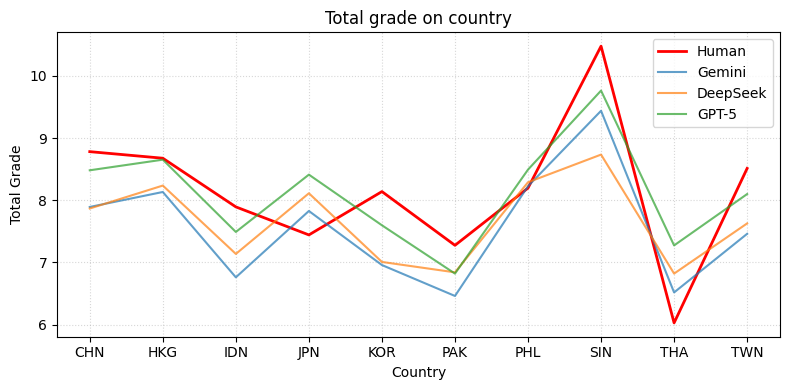

In [19]:
plot_benchmark(country_bm, 'country')

In [14]:
gender_bm = analysis_info.groupby('Sex').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    )
gender_bm

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg
Sex,,,,,
F,386,8.070984,7.580311,7.619171,8.137824
M,254,8.159843,7.477165,7.717323,8.048031


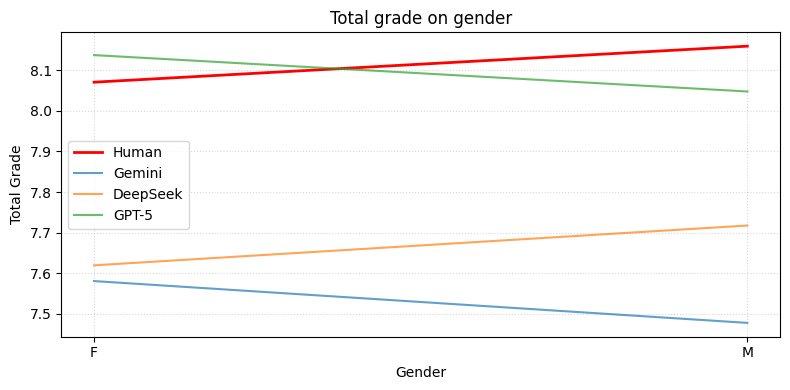

In [20]:
plot_benchmark(gender_bm, 'gender')

In [21]:
import numpy as np
age_overview = analysis_info.groupby('Age').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    )

age_overview['diff_gemini'] = np.abs(age_overview['human_avg'] - age_overview['gemini_avg'])
age_overview['diff_deepseek'] = np.abs(age_overview['human_avg'] - age_overview['deepseek_avg'])
age_overview['diff_gpt5'] = np.abs(age_overview['human_avg'] - age_overview['gpt5_avg'])

age_overview['max_diff'] = age_overview[['diff_gemini', 'diff_deepseek', 'diff_gpt5']].max(axis=1)

age_overview['worst_model'] = age_overview[['diff_gemini', 'diff_deepseek', 'diff_gpt5']].idxmax(axis=1)
age_overview = age_overview.drop(columns=['diff_gemini', 'diff_deepseek', 'diff_gpt5'])
age_overview.round(2)

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg,max_diff,worst_model
Age,,,,,,,
16,10,8.32,8.84,8.90,9.02,0.70,diff_gpt5
17,38,8.48,8.27,8.32,8.45,0.21,diff_gemini
18,86,7.49,7.20,7.27,7.86,0.37,diff_gpt5
19,146,7.94,7.59,7.67,8.14,0.35,diff_gemini
20,148,8.36,7.71,7.94,8.35,0.66,diff_gemini
21,94,8.33,7.44,7.60,8.14,0.88,diff_gemini
22,48,8.44,7.42,7.33,7.95,1.11,diff_deepseek
23,38,7.82,7.16,7.09,7.56,0.73,diff_deepseek
24,12,8.28,7.38,7.42,7.77,0.90,diff_gemini


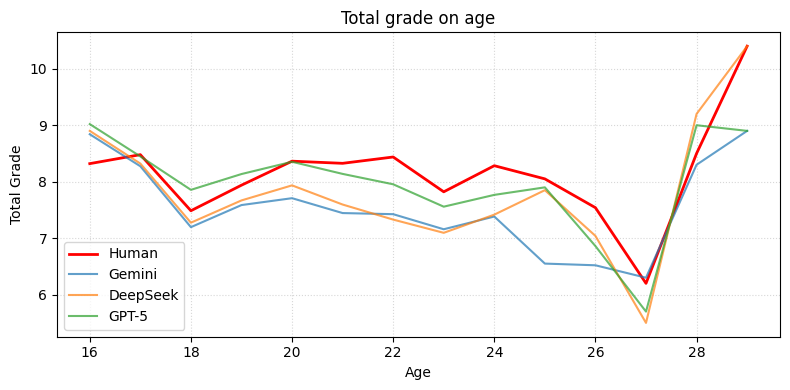

In [23]:
plot_benchmark(age_overview, 'age')

In [24]:
analysis_info.rename(columns={
    'Content (/12)': 'human_CON',
    'Organization (/12)': 'human_ORG',
    'Vocabulary (/12)': 'human_VOC',
    'Language Use (/12)': 'human_LNU',
    'Mechanics (/12)': 'human_MEC'
}, inplace=True)

all_means = analysis_info[[
    'human_CON', 'human_ORG', 'human_VOC', 'human_LNU', 'human_MEC',
    'gemini_CON', 'gemini_ORG', 'gemini_VOC', 'gemini_LNU', 'gemini_MEC',
    'deepseek_CON', 'deepseek_ORG', 'deepseek_VOC', 'deepseek_LNU', 'deepseek_MEC',
    'gpt5_CON', 'gpt5_ORG', 'gpt5_VOC', 'gpt5_LNU', 'gpt5_MEC'
]].mean()

pivot_data = all_means.reset_index()
pivot_data.columns = ['raw_name', 'Mean_Score']

pivot_data['Model'] = pivot_data['raw_name'].apply(lambda x: x.split('_')[0].upper())
pivot_data['Category'] = pivot_data['raw_name'].apply(lambda x: x.split('_')[1].upper())

final_pivot = pivot_data.pivot(index='Category', columns='Model', values='Mean_Score')

category_order = ['CON', 'ORG', 'VOC', 'LNU', 'MEC']
final_pivot = final_pivot.reindex(category_order)

range_row = final_pivot.max() - final_pivot.min()
final_pivot.loc['diff'] = range_row

final_pivot['diff'] = final_pivot.max(axis=1) - final_pivot.min(axis=1)

final_pivot.round(2)

Model,DEEPSEEK,GEMINI,GPT5,HUMAN,diff
Category,,,,,
CON,8.46,8.28,8.82,8.36,0.54
ORG,7.98,7.44,8.32,8.22,0.88
VOC,7.41,7.36,8.09,8.15,0.79
LNU,6.84,6.78,7.55,7.61,0.84
MEC,7.60,7.84,7.73,8.19,0.58
diff,1.62,1.51,1.27,0.75,0.87


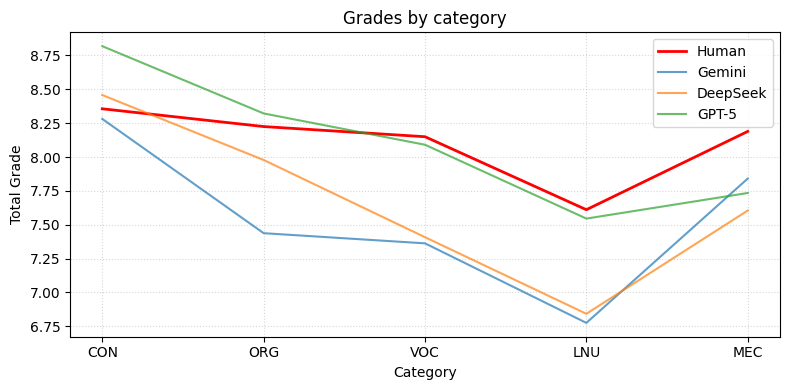

In [26]:
plt.figure(figsize=(8, 4))

plot_data = final_pivot.iloc[:-1]
plt.plot(plot_data['HUMAN'], label='Human', color='red', linewidth=2)
plt.plot(plot_data['GEMINI'], label='Gemini', alpha=0.7)
plt.plot(plot_data['DEEPSEEK'], label='DeepSeek', alpha=0.7)
plt.plot(plot_data['GPT5'], label='GPT-5', alpha=0.7)
plt.title('Grades by category')
plt.ylabel('Total Grade')
plt.xlabel('Category')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

plt.show()

In [27]:
profile_benchmark = analysis_info.groupby('Acad. Genre').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    )
profile_benchmark

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg
Acad. Genre,,,,,
Humanities,156,8.114103,7.457692,7.469231,8.033333
Life Sciences,16,7.637500,8.237500,8.800000,8.987500
Sciences & Technology,254,8.091339,7.474803,7.634646,8.027559
Social Sciences,198,8.212121,7.705051,7.815152,8.261616


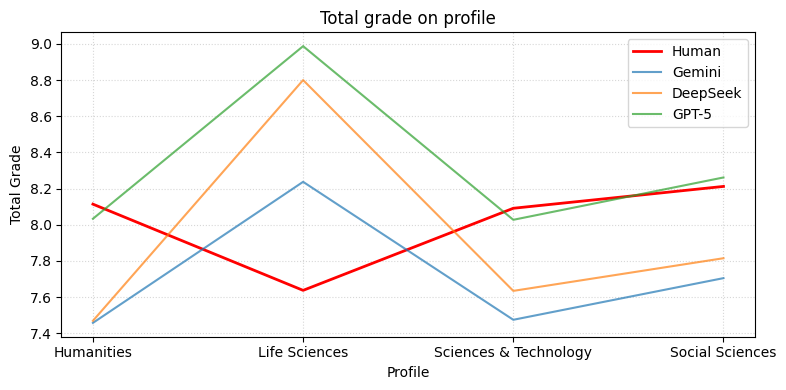

In [28]:
plot_benchmark(profile_benchmark, 'profile')

In [29]:
cefr_benchmarks = analysis_info.groupby('CEFR').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    )
cefr_benchmarks

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg
CEFR,,,,,
A2_0,120,7.178333,6.393333,5.796667,6.995000
B1_1,180,7.828889,7.250000,7.577778,7.812222
B1_2,202,8.177228,7.724752,8.027723,8.260396
B2_0,138,9.171014,8.642029,8.840580,9.211594


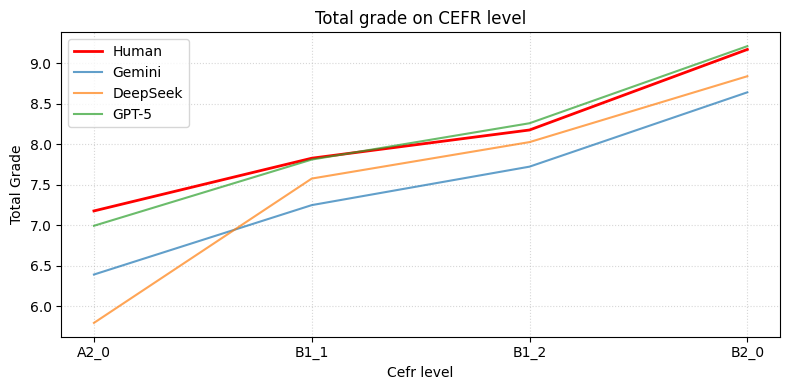

In [30]:
plot_benchmark(cefr_benchmarks, 'CEFR level')

In [44]:
topic_benchmarks = analysis_info.groupby('Topic').agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
    ).reset_index()
topic_benchmarks['Topic'] = topic_benchmarks['Topic'].apply(lambda x: 'Part-time job' if x == "PTJ" else "Smoking")
topic_benchmarks.set_index('Topic', inplace=True)

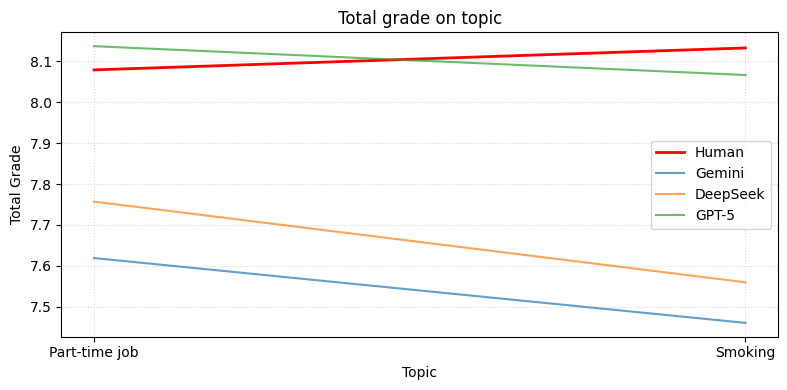

In [45]:
plot_benchmark(topic_benchmarks, 'topic')

In [53]:
analysis_info['Tokens'] = pd.to_numeric(analysis_info['Tokens'], errors='coerce')

max_tokens = int(analysis_info['Tokens'].max())
bins = np.arange(0, max_tokens + 20, 20)
analysis_info['Token_Bins'] = pd.cut(analysis_info['Tokens'], bins=bins)

wordcount_benchmarks = analysis_info.groupby('Token_Bins', observed=False).agg(
    total_essays=('student_id_x', 'count'),
    human_avg=('human_total', 'mean'),
    gemini_avg=('gemini_total', 'mean'),
    deepseek_avg=('deepseek_total', 'mean'),
    gpt5_avg=('gpt5_total', 'mean')
).dropna()

wordcount_benchmarks

,total_essays,human_avg,gemini_avg,deepseek_avg,gpt5_avg
Token_Bins,,,,,
"(160, 180]",1,6.600000,6.400000,5.200000,7.400000
"(180, 200]",45,7.893333,7.151111,7.271111,7.831111
"(200, 220]",274,7.864964,7.267883,7.316788,7.777372
"(220, 240]",129,8.213953,7.603101,7.733333,8.151938
"(240, 260]",73,8.216438,7.567123,7.616438,8.024658
"(260, 280]",46,8.778261,8.208696,8.339130,8.900000
"(280, 300]",44,8.427273,8.236364,8.595455,8.940909
"(300, 320]",22,8.227273,8.127273,8.745455,8.963636
"(320, 340]",6,9.366667,8.933333,9.366667,9.533333


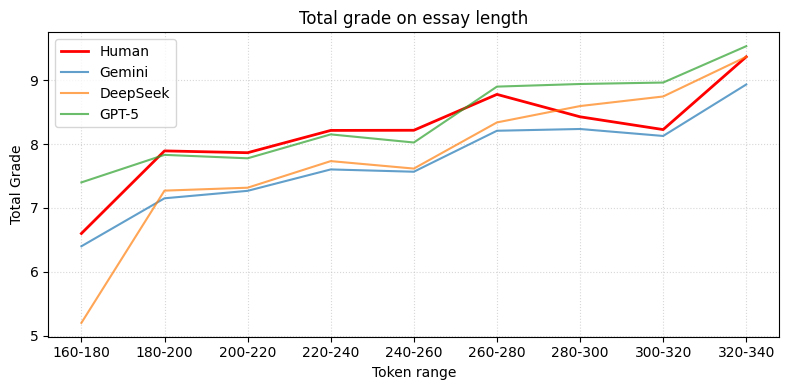

In [54]:
plt.figure(figsize=(8, 4))

x_labels = [f"{int(b.left)}-{int(b.right)}" for b in wordcount_benchmarks.index]

plt.plot(x_labels, wordcount_benchmarks['human_avg'], label='Human', color='red', linewidth=2)
plt.plot(x_labels, wordcount_benchmarks['gemini_avg'], label='Gemini', alpha=0.7)
plt.plot(x_labels, wordcount_benchmarks['deepseek_avg'], label='DeepSeek', alpha=0.7)
plt.plot(x_labels, wordcount_benchmarks['gpt5_avg'], label='GPT-5', alpha=0.7)
plt.title('Total grade on essay length')
plt.ylabel('Total Grade')
plt.xlabel('Token range')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

plt.show()